In [ ]:
## Superstore Data Visualization

## Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [5]:
df = pd.read_csv("../02_data_cleaning/cleaned_superstore.csv")


## Sales by Region

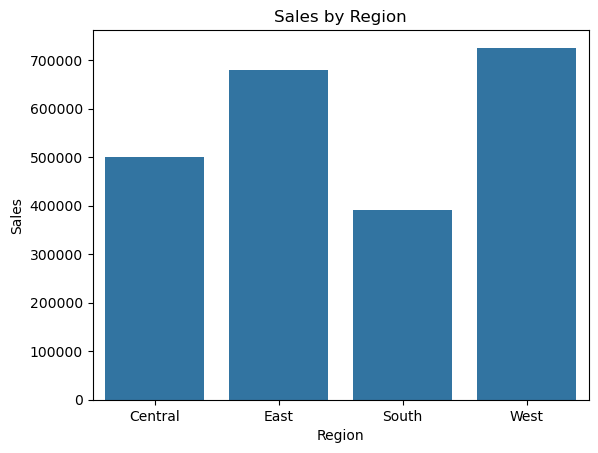

In [6]:
sales_region = df.groupby("Region", as_index=False)["Sales"].sum()

sns.barplot(data=sales_region, x="Region", y="Sales")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

## Profit by Region

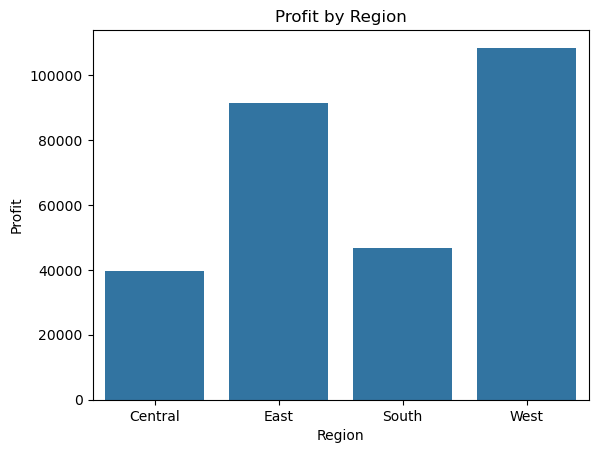

In [7]:
profit_region = df.groupby("Region", as_index=False)["Profit"].sum()

sns.barplot(data=profit_region, x="Region", y="Profit")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

## Sales by Category

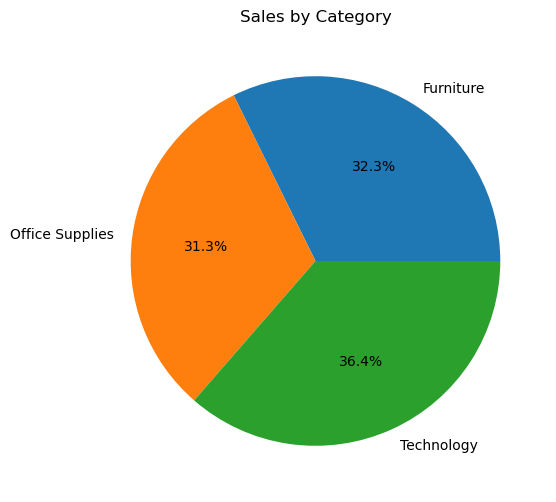

In [8]:
sales_category = df.groupby("Category", as_index=False)["Sales"].sum()

plt.figure(figsize=(6,6))

plt.pie(
    sales_category["Sales"],
    labels=sales_category["Category"],
    autopct="%1.1f%%"
)

plt.title("Sales by Category")

plt.show()

## Top 10 Customers

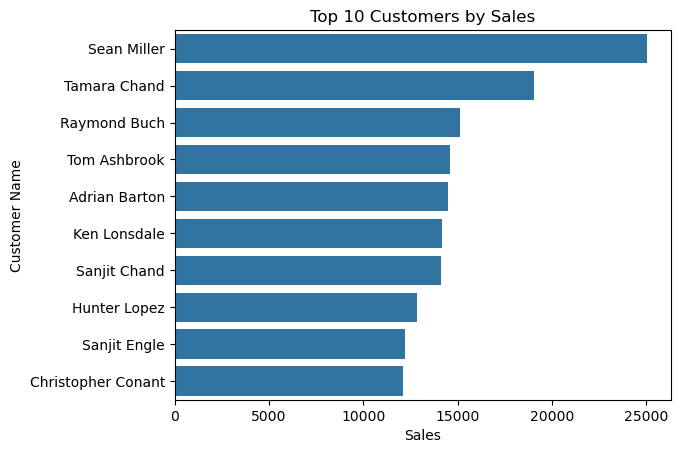

In [9]:
top_customers = (
    df.groupby("Customer Name", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
      .head(10)
)

sns.barplot(data=top_customers, x="Sales", y="Customer Name")

plt.title("Top 10 Customers by Sales")

plt.show()

## Monthly Sales Trend

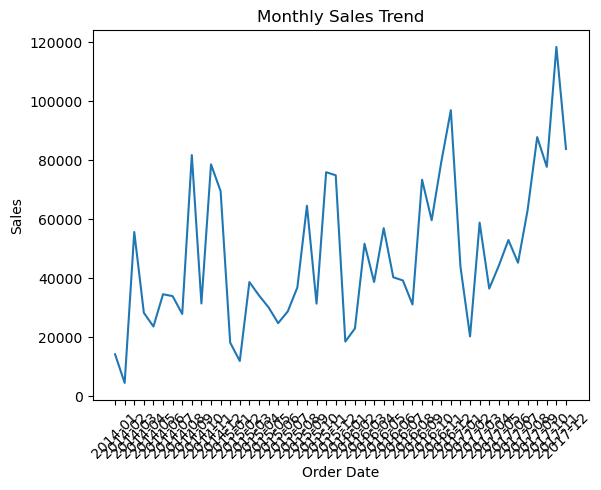

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

sns.lineplot(data=monthly_sales, x="Order Date", y="Sales")

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.show()

## Profit Distribution

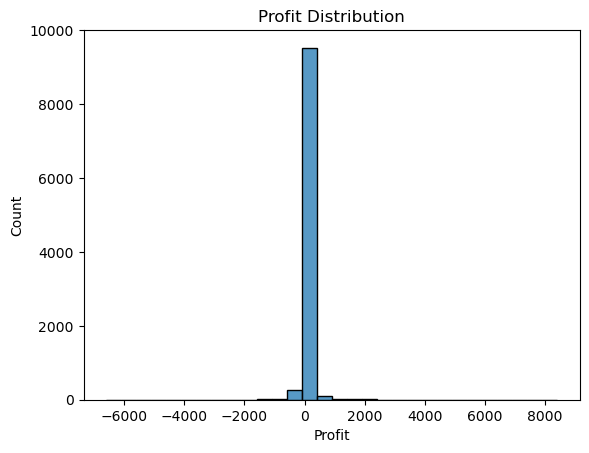

In [11]:
sns.histplot(df["Profit"], bins=30)

plt.title("Profit Distribution")

plt.show()